## Phase 7 — Model Comparison and Analysis

This phase presents a comprehensive comparison of all models developed throughout the pipeline,
including rule-based, classical machine learning, and transformer-based approaches.

Predictions from each model are evaluated using consistent metrics, with Macro F1 as the primary
criterion due to class imbalance in the DDI dataset. Additional metrics — balanced accuracy, MCC,
and Cohen's Kappa — provide deeper insight into model robustness.

Beyond quantitative evaluation, this phase includes statistical significance testing, detailed
visualisations, and a focused error analysis. The `best_model` variable determined here is
persisted to disk so Phase 8 can load it dynamically rather than hardcoding a model name.

## 1. Setup

Directories, plot style, model ordering, and colour maps are initialised here.
All paths and constants come from `config.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../'))
from config import *

import json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import sparse
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
)

warnings.filterwarnings('ignore')

FIG_DIR = Path(str(PLOTS_COMPARISON_DIR))
DAT_DIR = Path(str(METRICS_COMPARISON_DIR))
FIG_DIR.mkdir(parents=True, exist_ok=True)
DAT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

# Canonical model display order — used for consistent axis ordering
MODEL_ORDER = [
    'Rule-based', 'Naive Bayes', 'Logistic Regression',
    'Random Forest', 'Linear SVM',
    'BioBERT', 'PubMedBERT', 'SciBERT',
]

# Shared helper: maps a model name to its tier
def model_type(name):
    if name == 'Rule-based': return 'Rule-based'
    if name in ('BioBERT', 'PubMedBERT', 'SciBERT'): return 'Transformer'
    return 'Classical ML'

# Shared class name list (alphabetical — matches LabelEncoder order)
CLASS_NAMES = [ID2LABEL[i] for i in sorted(ID2LABEL)]


## 2. Loading Predictions

Classical models are loaded from saved artefact PKLs and re-run on the test feature matrix.
The rule-based model is reconstructed from keyword rules (no saved state needed).
Transformer predictions are loaded from the `.npy` arrays saved by Phase 6.

Only models with available predictions enter the comparison.

In [2]:
y_test = np.load(Y_TEST_NPY)
test_df = pd.read_csv(TEST_PROCESSED)
test_df['label'] = test_df['interaction_type'].map(LABEL2ID)

print(f'Ground truth: {len(y_test):,} test samples')

all_preds = {}

print('\nLoading classical model predictions')

X_test = sparse.load_npz(TEST_FEATURES_NPZ)

with open(LABEL_ENCODER_PKL, 'rb') as f:
    encoder = pickle.load(f)

for fname, name in [
    ('naive_bayes.pkl', 'Naive Bayes'),
    ('logistic_regression.pkl', 'Logistic Regression'),
    ('random_forest.pkl', 'Random Forest'),
    ('svm.pkl', 'Linear SVM'),
]:
    fpath = os.path.join(str(FEATURES_ARTEFACTS_DIR), fname)
    if os.path.exists(fpath):
        with open(fpath, 'rb') as f:
            m = pickle.load(f)
        if 'naive' in fname:
            X_nb = np.clip(X_test.toarray().astype(np.float32), 0, None)
            wb_idx = X_test.shape[1] - 24 + 3
            X_nb[:, wb_idx] = np.clip(X_nb[:, wb_idx], 0, None)
            all_preds[name] = m.predict(X_nb)
        else:
            all_preds[name] = m.predict(X_test)
        print(f'{name:<22}')
    else:
        print(f'{name:<22} MISSING — skipped')

RULES = {
    'mechanism': {'inhibit','induce','metabolis','metaboliz','cyp','enzyme',
                  'absorption','clearance','half-life','bioavailability','pharmacokinetic'},
    'effect': {'bleeding','toxicity','sedation','hypotension','bradycardia',
                  'adverse','side effect','prolonged','elevated'},
    'advise': {'contraindicated','avoid','caution','recommend','monitor',
                  'warning','should not','do not','concomitant'},
    'int': {'interact','interaction','combined with','co-administration','combination'},
}

def rule_predict(sentences):
    preds = []
    for s in sentences:
        sl, pred = str(s).lower(), 'false'
        for lbl in ['mechanism', 'effect', 'advise', 'int']:
            if any(kw in sl for kw in RULES[lbl]):
                pred = lbl; break
        preds.append(pred)
    return preds

all_preds['Rule-based'] = encoder.transform(rule_predict(test_df['sentence_cleaned']))
print(f'  {"Rule-based":<22} reconstructed from keyword rules')

print('\nLoading transformer predictions')
for trans_name, pred_path in [
    ('BioBERT', BIOBERT_PREDS_NPY),
    ('PubMedBERT', PUBMEDBERT_PREDS_NPY),
    ('SciBERT', SCIBERT_PREDS_NPY),
]:
    if os.path.exists(pred_path):
        all_preds[trans_name] = np.load(pred_path)
        print(f'{trans_name:<22}')
    else:
        phase = 'a' if trans_name == 'BioBERT' else 'b' if trans_name == 'PubMedBERT' else 'c'
        print(f'{trans_name:<22} NOT FOUND — run Phase 6{phase} first')

available = [m for m in MODEL_ORDER if m in all_preds]
print(f'\nModels with predictions : {available}')
print(f'Models missing : {[m for m in MODEL_ORDER if m not in all_preds]}')


Ground truth: 6,657 test samples

Loading classical model predictions
Naive Bayes           
Logistic Regression   
Random Forest         
Linear SVM            
  Rule-based             reconstructed from keyword rules

Loading transformer predictions
BioBERT               
PubMedBERT            
SciBERT               

Models with predictions : ['Rule-based', 'Naive Bayes', 'Logistic Regression', 'Random Forest', 'Linear SVM', 'BioBERT', 'PubMedBERT', 'SciBERT']
Models missing : []


## 3. Model Comparison Metrics

All models are evaluated with the same metric set:
- **Macro F1** (primary — SemEval-2013 official metric; equal weight per class)
- Balanced accuracy, MCC, Cohen's Kappa (complementary robustness measures)
- Per-class F1 for all five interaction types

Models are ranked by Macro F1. The best overall model and the best within each tier
(Rule-based / Classical ML / Transformer) are identified and stored for use in Phase 8.

In [3]:
metric_rows = []

for name in available:
    preds = all_preds[name]
    rep = classification_report(
        y_test, preds, target_names=CLASS_NAMES,
        output_dict=True, zero_division=0
    )
    row = {
        'Model': name,
        'Type': model_type(name),
        'Accuracy': round(rep['accuracy'], 4),
        'Bal. Accuracy': round(balanced_accuracy_score(y_test, preds), 4),
        'Macro F1': round(rep['macro avg']['f1-score'], 4),
        'MCC': round(matthews_corrcoef(y_test, preds), 4),
        'Kappa': round(cohen_kappa_score(y_test, preds), 4),
    }
    for lbl in LABEL_ORDER:
        row[f'F1({lbl})'] = round(rep[lbl]['f1-score'], 3)
    metric_rows.append(row)

full_df = (
    pd.DataFrame(metric_rows)
    .sort_values('Macro F1', ascending=False)
    .reset_index(drop=True)
)

best_model = full_df.iloc[0]['Model']

best_clf = (
    full_df[full_df['Type'] == 'Classical ML']['Model'].iloc[0]
    if 'Classical ML' in full_df['Type'].values else None
)
best_trans = (
    full_df[full_df['Type'] == 'Transformer']['Model'].iloc[0]
    if 'Transformer' in full_df['Type'].values else None
)
trans_available = [m for m in ['BioBERT', 'PubMedBERT', 'SciBERT'] if m in all_preds]

pd.set_option('display.width', 240)
pd.set_option('display.max_columns', 20)
print('-'*110)
print('FULL MODEL COMPARISON — ranked by Macro F1 (SemEval-2013 official metric)')
print('-'*110)
print(full_df.to_string(index=False))
print(f'\nBest model overall : {best_model} ({full_df.iloc[0]["Macro F1"]:.4f})')
for tier in ['Rule-based', 'Classical ML', 'Transformer']:
    tier_df = full_df[full_df['Type'] == tier]
    if not tier_df.empty:
        b = tier_df.iloc[0]
        print(f'  Best {tier:<14} : {b["Model"]} ({b["Macro F1"]:.4f})')

full_df.to_csv(FULL_COMPARISON_CSV, index=False)

best_model_info = {
    'best_model': best_model,
    'best_transformer': best_trans,
    'best_classical': best_clf,
    'trans_available': trans_available,
}
best_model_json = str(DAT_DIR / 'best_model_info.json')
with open(best_model_json, 'w') as f:
    json.dump(best_model_info, f, indent=2)


--------------------------------------------------------------------------------------------------------------
FULL MODEL COMPARISON — ranked by Macro F1 (SemEval-2013 official metric)
--------------------------------------------------------------------------------------------------------------
              Model         Type  Accuracy  Bal. Accuracy  Macro F1    MCC  Kappa  F1(false)  F1(effect)  F1(mechanism)  F1(advise)  F1(int)
            SciBERT  Transformer    0.9177         0.7476    0.7307 0.7126 0.7101      0.957       0.693          0.706       0.801    0.496
         PubMedBERT  Transformer    0.9156         0.7291    0.7258 0.6964 0.6953      0.956       0.705          0.679       0.754    0.535
            BioBERT  Transformer    0.9013         0.7102    0.6799 0.6551 0.6530      0.948       0.666          0.657       0.759    0.369
         Linear SVM Classical ML    0.8035         0.6311    0.5459 0.4555 0.4349      0.888       0.405          0.528       0.504    0.404

## 4. Statistical Significance Testing (McNemar's Test)

McNemar's test compares two classifiers on the *same* test set by examining discordant
prediction pairs — samples where one model is correct and the other is wrong.

- H₀: both models make errors on the same samples (no real difference)
- p < 0.05: reject H₀ — the difference is statistically significant
- Uses exact binomial test for n_disc < 25, Yates-corrected chi-squared otherwise

Pairs tested: Best Transformer vs Best Classical, Best Classical vs Rule-based,
and all three pairwise transformer comparisons.

In [4]:
try:
    from statsmodels.stats.contingency_tables import mcnemar as sm_mcnemar
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print('statsmodels not found — install with: pip install statsmodels')


def mcnemar_test(y_true, preds_a, preds_b, name_a, name_b):
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)
    b = int(np.sum( correct_a & ~correct_b))  
    c = int(np.sum(~correct_a &  correct_b))   
    n_disc = b + c

    f1_a = f1_score(y_true, preds_a, average='macro', zero_division=0)
    f1_b = f1_score(y_true, preds_b, average='macro', zero_division=0)

    if n_disc < 25:
        try:
            from scipy.stats import binomtest
            p = binomtest(b, n_disc, 0.5).pvalue
        except ImportError:
            from scipy.stats import binom_test
            p = binom_test(b, n_disc, 0.5)
        method = 'exact binomial'
    elif HAS_STATSMODELS:
        n_both_correct = int(np.sum( correct_a &  correct_b))
        n_both_wrong   = int(np.sum(~correct_a & ~correct_b))
        table  = np.array([[n_both_correct, b], [c, n_both_wrong]])
        result = sm_mcnemar(table, exact=False, correction=True)
        p, method = result.pvalue, 'McNemar chi² (Yates correction)'
    else:
        from scipy.stats import chi2
        stat = (abs(b - c) - 1)**2 / (b + c) if (b + c) > 0 else 0
        p    = 1 - chi2.cdf(stat, df=1)
        method = 'McNemar chi² (manual)'

    sig = 'SIGNIFICANT ' if p < 0.05 else 'not significant'
    dir_str = f'{name_a} > {name_b}' if f1_a > f1_b else f'{name_b} > {name_a}' if f1_b > f1_a else 'tied'

    print(f'{name_a} vs {name_b}')
    print(f'Macro F1 : {name_a}={f1_a:.4f}  {name_b}={f1_b:.4f}  Δ={f1_a-f1_b:+.4f}')
    print(f'Discordant: b={b}  c={c}  total={n_disc}')
    print(f'p-value : {p:.4f}  [{method}]')
    print(f'Result : {sig} — {dir_str}')
    print()
    return p


stat_results = {}
print('-'*70)
print("McNemar's Test — Statistical Significance")
print('-'*70)
print('H0: both models make errors on the same samples (no real difference)')
print('p < 0.05 => reject H0 => difference is statistically significant')
print()

test_pairs = [
    (best_trans, best_clf, 'Best Transformer vs Best Classical'),
    (best_clf, 'Rule-based',  'Best Classical vs Rule-based'),
    ('BioBERT', 'PubMedBERT', 'BioBERT vs PubMedBERT'),
    ('BioBERT', 'SciBERT', 'BioBERT vs SciBERT'),
    ('PubMedBERT', 'SciBERT', 'PubMedBERT vs SciBERT'),
]

for model_a, model_b, label in test_pairs:
    if model_a and model_b and model_a in all_preds and model_b in all_preds:
        print(f'Test: {label}')
        p = mcnemar_test(y_test, all_preds[model_a], all_preds[model_b], model_a, model_b)
        stat_results[label] = {'model_a': model_a, 'model_b': model_b,
                                'p_value': p, 'significant': p < 0.05}
    else:
        missing = [m for m in [model_a, model_b] if m and m not in all_preds]
        if missing:
            print(f'Test: {label}  — SKIPPED (missing: {missing})')

stat_df = pd.DataFrame(list(stat_results.values()))
if not stat_df.empty:
    stat_df.to_csv(str(DAT_DIR / 'statistical_tests.csv'), index=False)


----------------------------------------------------------------------
McNemar's Test — Statistical Significance
----------------------------------------------------------------------
H0: both models make errors on the same samples (no real difference)
p < 0.05 => reject H0 => difference is statistically significant

Test: Best Transformer vs Best Classical
SciBERT vs Linear SVM
Macro F1 : SciBERT=0.7307  Linear SVM=0.5459  Δ=+0.1848
Discordant: b=944  c=184  total=1128
p-value : 0.0000  [McNemar chi² (Yates correction)]
Result : SIGNIFICANT  — SciBERT > Linear SVM

Test: Best Classical vs Rule-based
Linear SVM vs Rule-based
Macro F1 : Linear SVM=0.5459  Rule-based=0.1995  Δ=+0.3464
Discordant: b=3693  c=438  total=4131
p-value : 0.0000  [McNemar chi² (Yates correction)]
Result : SIGNIFICANT  — Linear SVM > Rule-based

Test: BioBERT vs PubMedBERT
BioBERT vs PubMedBERT
Macro F1 : BioBERT=0.6799  PubMedBERT=0.7258  Δ=-0.0459
Discordant: b=162  c=257  total=419
p-value : 0.0000  [McNemar 

## 5. Model Performance Visualisation

Three-panel chart: Macro F1 (primary), MCC (robust imbalance metric), and a
multi-metric grouped bar for a complete picture. A dashed boundary separates
Classical ML from Transformer tiers.

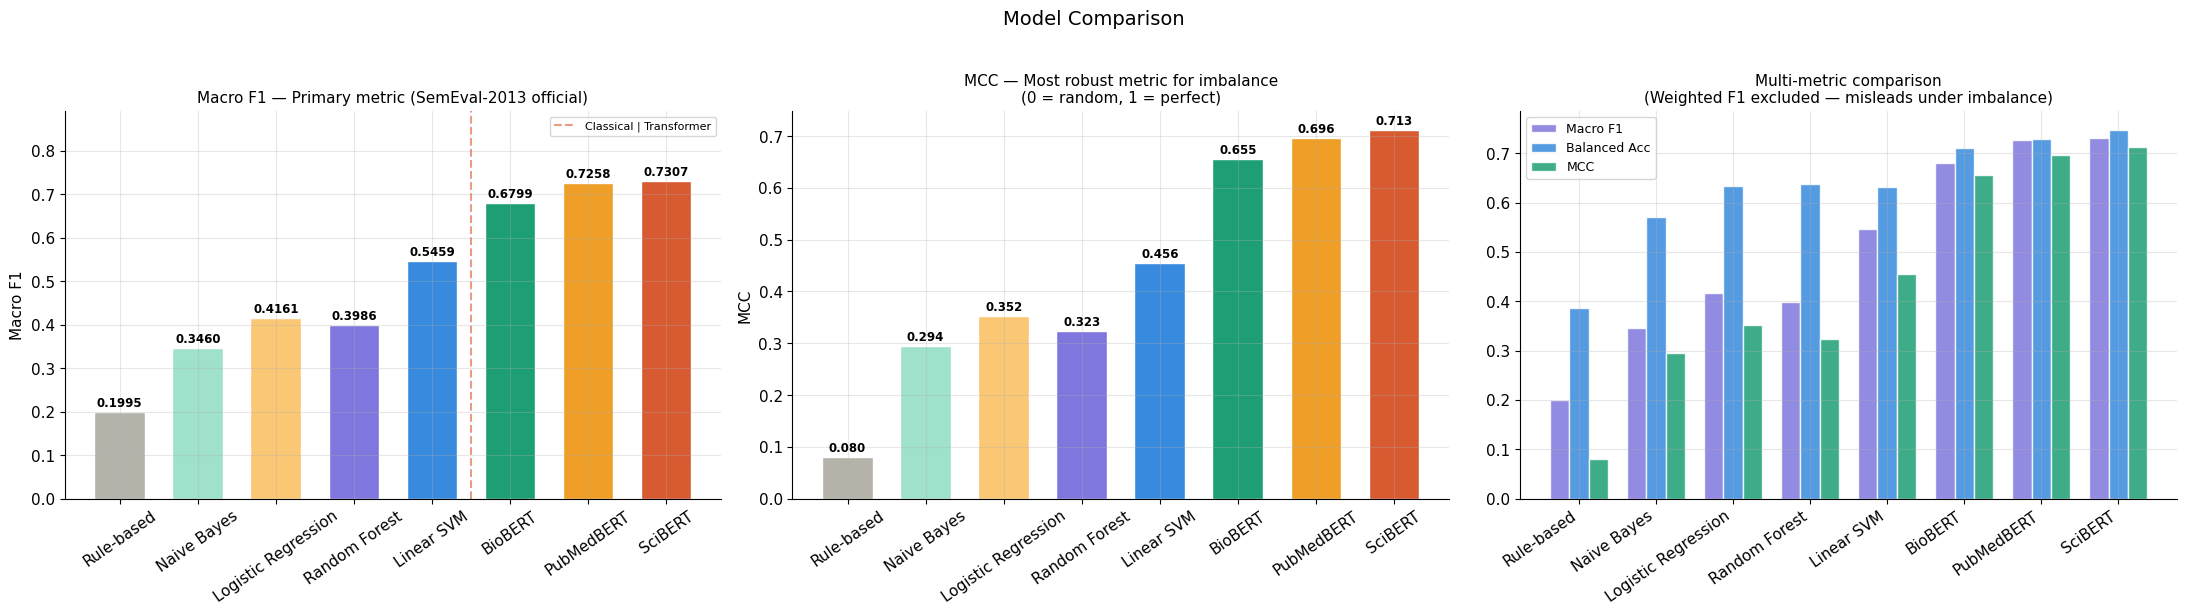

In [5]:
colours   = [MODEL_COLOURS.get(m, '#888780') for m in available]
macro_f1s = [f1_score(y_test, all_preds[m], average='macro', zero_division=0) for m in available]
mcc_vals  = [matthews_corrcoef(y_test, all_preds[m]) for m in available]
bal_accs  = [balanced_accuracy_score(y_test, all_preds[m]) for m in available]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Panel 1: Macro F1
bars = axes[0].bar(available, macro_f1s, color=colours, edgecolor='white', width=0.65)
for bar, val in zip(bars, macro_f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

classical_in_avail = [m for m in available if model_type(m) == 'Classical ML']
trans_in_avail     = [m for m in available if model_type(m) == 'Transformer']
if classical_in_avail and trans_in_avail:
    boundary = (available.index(classical_in_avail[-1]) + available.index(trans_in_avail[0])) / 2
    axes[0].axvline(boundary, color='#D85A30', linestyle='--', alpha=0.6, label='Classical | Transformer')
    axes[0].legend(fontsize=8)

axes[0].set_title('Macro F1 — Primary metric (SemEval-2013 official)', fontsize=11)
axes[0].set_ylabel('Macro F1')
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_ylim(0, max(macro_f1s) * 1.22)

# Panel 2: MCC
bars2 = axes[1].bar(available, mcc_vals, color=colours, edgecolor='white', width=0.65)
for bar, val in zip(bars2, mcc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axes[1].set_title('MCC — Most robust metric for imbalance\n(0 = random, 1 = perfect)', fontsize=11)
axes[1].set_ylabel('MCC')
axes[1].tick_params(axis='x', rotation=35)

# Panel 3: Multi-metric grouped bar
x = np.arange(len(available))
w = 0.25
axes[2].bar(x - w, macro_f1s, w, label='Macro F1', color='#7F77DD', alpha=0.85, edgecolor='white')
axes[2].bar(x, bal_accs,  w, label='Balanced Acc',  color='#378ADD', alpha=0.85, edgecolor='white')
axes[2].bar(x + w, mcc_vals,  w, label='MCC', color='#1D9E75', alpha=0.85, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(available, rotation=35, ha='right')
axes[2].set_title('Multi-metric comparison\n(Weighted F1 excluded — misleads under imbalance)', fontsize=11)
axes[2].legend(fontsize=9)

plt.suptitle('Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()

out_path = str(FIG_DIR / 'full_comparison.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()


## 6. Per-Class Performance Analysis

F1 scores for each of the five interaction types are visualised as a heatmap.
The delta panel shows where the best transformer outperforms (green) or regresses (red)
versus the best classical model.

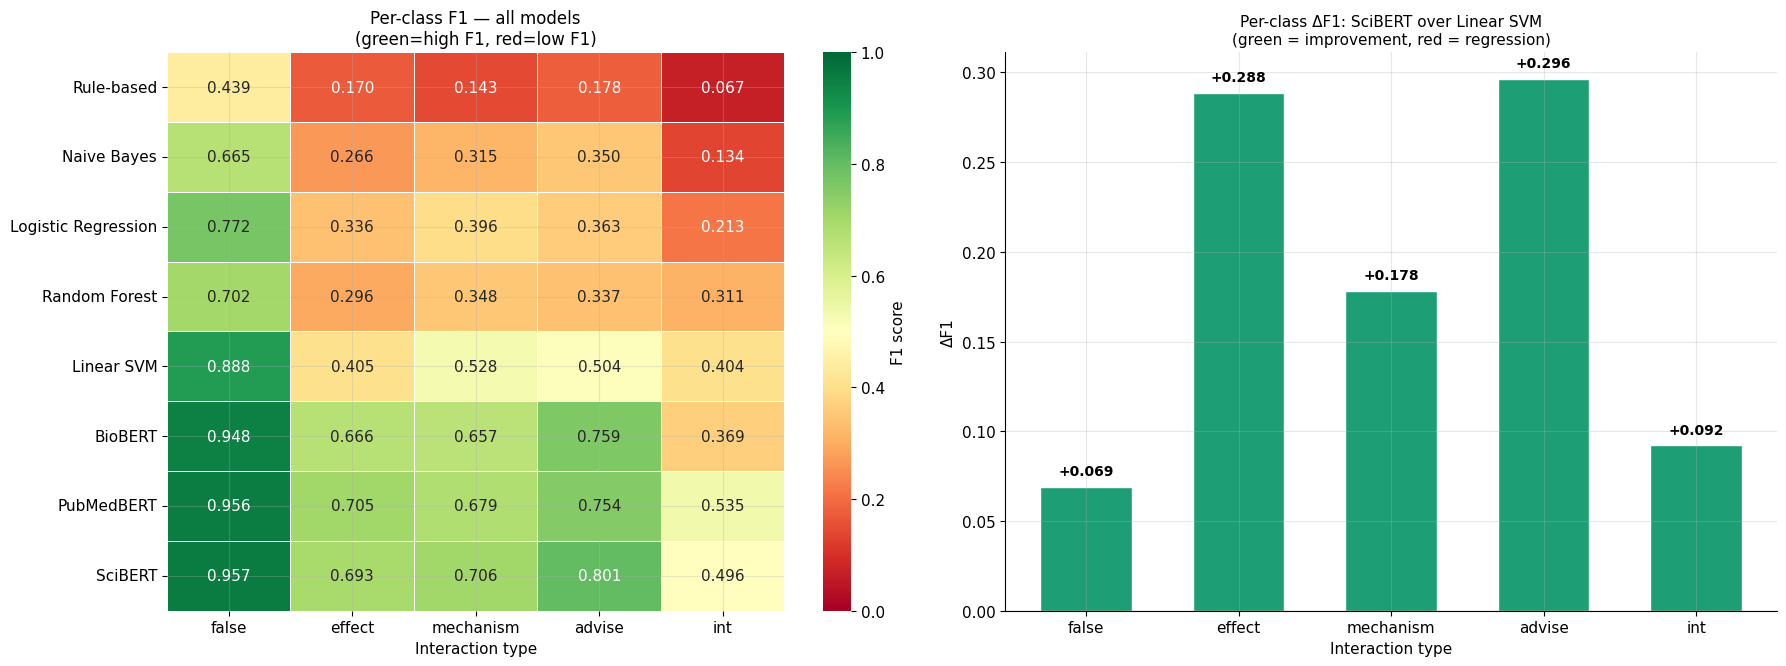

In [6]:
per_class = {}
for name in available:
    rep = classification_report(y_test, all_preds[name],
                                target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    per_class[name] = [rep[lbl]['f1-score'] for lbl in LABEL_ORDER]

hm_df = pd.DataFrame(per_class, index=LABEL_ORDER).T.reindex(available)

fig, axes = plt.subplots(1, 2, figsize=(18, max(4, len(available) * 0.85)))

sns.heatmap(hm_df, ax=axes[0], annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, vmin=0, vmax=1, cbar_kws={'label': 'F1 score'})
axes[0].set_title('Per-class F1 — all models\n(green=high F1, red=low F1)', fontsize=12)
axes[0].set_xlabel('Interaction type')

if best_trans and best_clf and best_trans in hm_df.index and best_clf in hm_df.index:
    delta    = hm_df.loc[best_trans] - hm_df.loc[best_clf]
    bar_cols = ['#1D9E75' if v >= 0 else '#D85A30' for v in delta]
    axes[1].bar(LABEL_ORDER, delta.values, color=bar_cols, edgecolor='white', width=0.6)
    axes[1].axhline(0, color='black', linewidth=0.8, alpha=0.5)
    for i, val in enumerate(delta.values):
        axes[1].text(i, val + (0.005 if val >= 0 else -0.015), f'{val:+.3f}',
                     ha='center', va='bottom' if val >= 0 else 'top', fontsize=10, fontweight='bold')
    axes[1].set_title(f'Per-class ΔF1: {best_trans} over {best_clf}\n'
                      '(green = improvement, red = regression)', fontsize=11)
    axes[1].set_xlabel('Interaction type')
    axes[1].set_ylabel('ΔF1')
else:
    axes[1].text(0.5, 0.5, 'Run Phase 6 notebooks first', ha='center', va='center',
                 transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
out_path = str(FIG_DIR / 'perclass_heatmap.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()


## 7. Transformer Head-to-Head Comparison

Focused comparison of BioBERT, PubMedBERT, and SciBERT on Macro F1, MCC,
and per-class F1. The PubMedBERT vs SciBERT significance result from Section 4
should be consulted when interpreting near-ties.

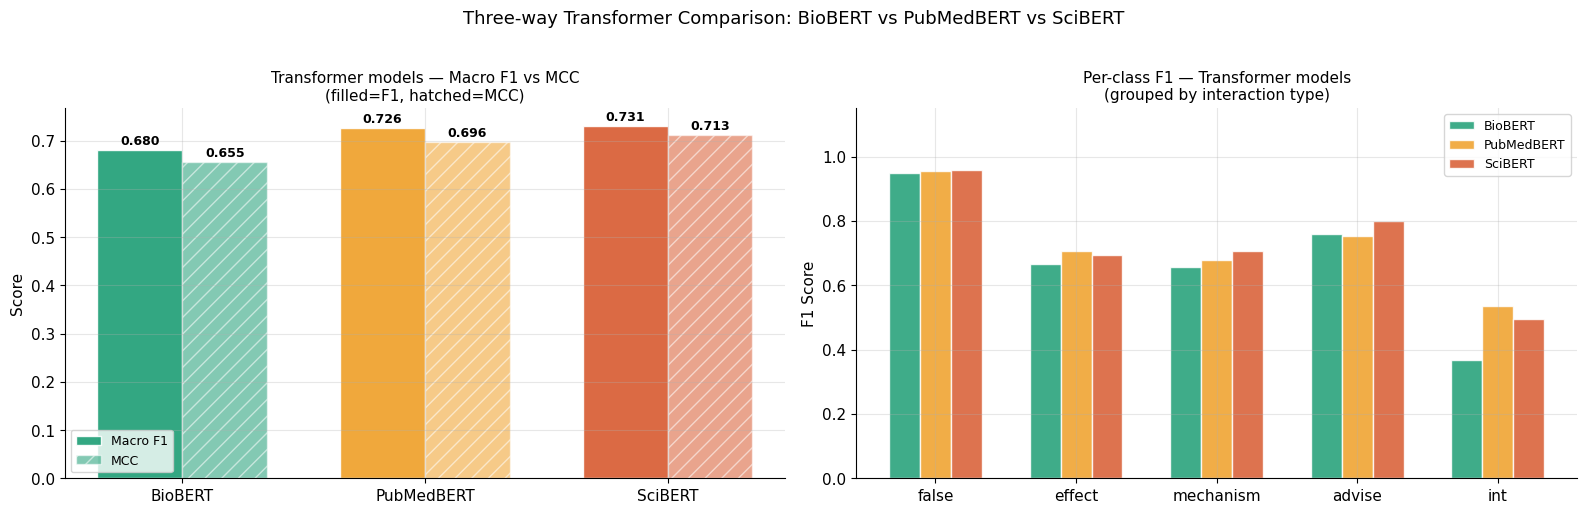

In [7]:
if not trans_available:
    print('No transformer predictions available — run Phase 6a/6b/6c first.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    x = np.arange(len(trans_available))
    w = 0.35
    t_f1s = [f1_score(y_test, all_preds[m], average='macro', zero_division=0) for m in trans_available]
    t_mcc = [matthews_corrcoef(y_test, all_preds[m]) for m in trans_available]
    t_cols = [MODEL_COLOURS.get(m, '#888') for m in trans_available]

    b1 = axes[0].bar(x - w/2, t_f1s, w, label='Macro F1', color=t_cols, alpha=0.9, edgecolor='white')
    b2 = axes[0].bar(x + w/2, t_mcc, w, label='MCC',      color=t_cols, alpha=0.55, edgecolor='white', hatch='//')
    for bar, val in list(zip(b1, t_f1s)) + list(zip(b2, t_mcc)):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(trans_available)
    axes[0].set_title('Transformer models — Macro F1 vs MCC\n(filled=F1, hatched=MCC)', fontsize=11)
    axes[0].set_ylabel('Score')
    axes[0].legend(fontsize=9)

    n_trans = len(trans_available)
    x2 = np.arange(len(LABEL_ORDER))
    bar_width = 0.22
    for j, (tname, tcol) in enumerate([(m, MODEL_COLOURS.get(m, '#888')) for m in trans_available]):
        rep = classification_report(y_test, all_preds[tname], target_names=CLASS_NAMES,
                                    output_dict=True, zero_division=0)
        f1s    = [rep[lbl]['f1-score'] for lbl in LABEL_ORDER]
        offset = (j - n_trans/2 + 0.5) * bar_width
        axes[1].bar(x2 + offset, f1s, bar_width, label=tname, color=tcol, alpha=0.85, edgecolor='white')
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(LABEL_ORDER)
    axes[1].set_title('Per-class F1 — Transformer models\n(grouped by interaction type)', fontsize=11)
    axes[1].set_ylabel('F1 Score')
    axes[1].legend(fontsize=9)
    axes[1].set_ylim(0, 1.15)

    plt.suptitle('Three-way Transformer Comparison: BioBERT vs PubMedBERT vs SciBERT',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    out_path = str(FIG_DIR / 'transformer_threeway.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()


## 8. Normalised Confusion Matrices

One matrix per tier (Rule-based / Best Classical / Best Transformer).
The diagonal shows per-class recall; off-diagonal cells reveal confusion patterns.

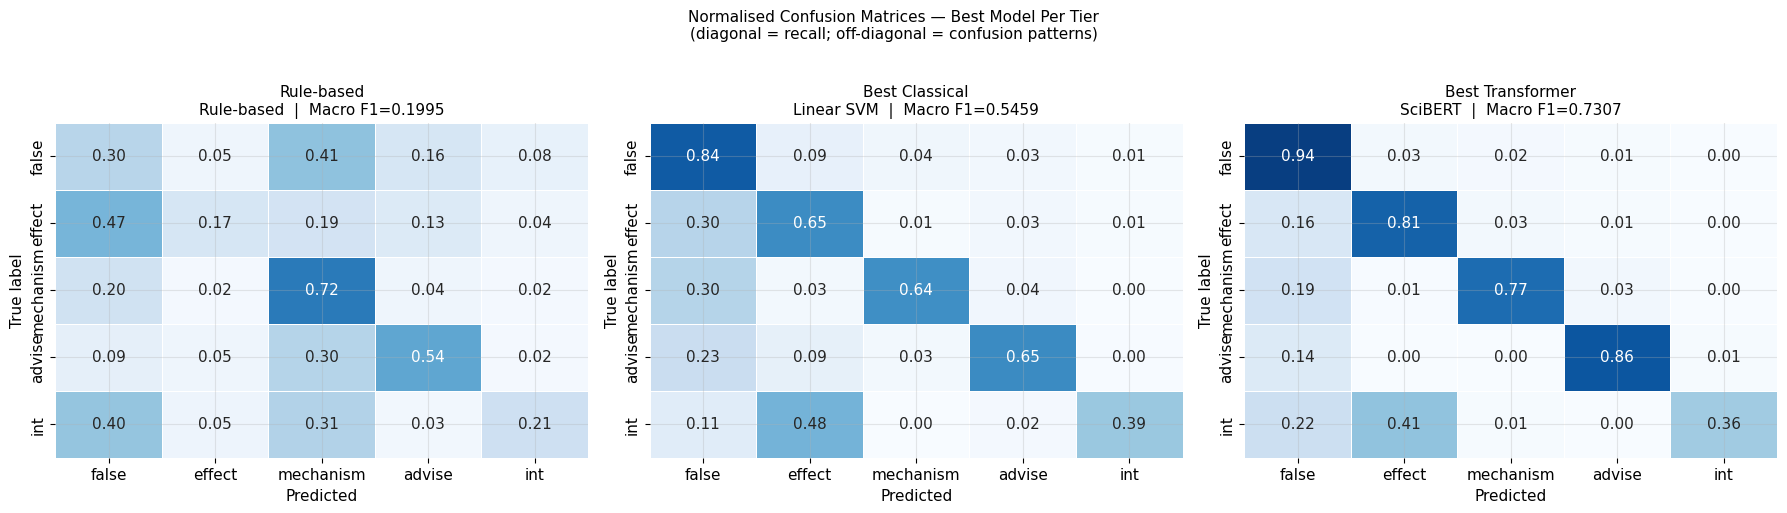

In [8]:
showcase = {}
for tier, label in [('Rule-based','Rule-based'), ('Classical ML','Best Classical'), ('Transformer','Best Transformer')]:
    tier_rows = full_df[full_df['Type'] == tier]
    if not tier_rows.empty:
        best_in_tier = tier_rows.iloc[0]['Model']
        if best_in_tier in all_preds:
            showcase[label] = best_in_tier

n_panels = len(showcase)
if n_panels == 0:
    print('No predictions available for showcase.')
else:
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5))
    if n_panels == 1: axes = [axes]
    idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
    for ax, (panel_label, model_name) in zip(axes, showcase.items()):
        preds = all_preds[model_name]
        cm = confusion_matrix(y_test, preds)
        cm_ord  = cm[np.ix_(idx, idx)]
        rsums = cm_ord.sum(axis=1, keepdims=True)
        rsums[rsums == 0] = 1
        cm_norm = cm_ord / rsums
        f1 = f1_score(y_test, preds, average='macro', zero_division=0)
        sns.heatmap(cm_norm, ax=ax, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
                    vmin=0, vmax=1, cbar=False, linewidths=0.5)
        ax.set_title(f'{panel_label}\n{model_name}  |  Macro F1={f1:.4f}', fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True label')

    plt.suptitle('Normalised Confusion Matrices — Best Model Per Tier\n'
                 '(diagonal = recall; off-diagonal = confusion patterns)', fontsize=11, y=1.02)
    plt.tight_layout()
    out_path = str(FIG_DIR / 'confusion_matrices.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()


## 9. Error Analysis (Best Model)

A focused summary of error patterns for the best model. Detailed categorisation
and visualisation are deliberately deferred to Phase 8, which runs this analysis
more thoroughly using `best_model_info.json` to avoid duplicating logic.

Three summary statistics are reported here:
1. Top misclassification patterns (true → predicted)
2. Dangerous misses — real interactions labelled as `false`
3. Persistent errors — samples every available model gets wrong

In [9]:
if best_model not in all_preds:
    print(f'Best model ({best_model}) predictions not available.')
else:
    best_col = best_model.lower().replace(' ', '_').replace('-', '_') + '_pred'
    interaction_classes = [l for l in LABEL_ORDER if l != 'false']

    test_df['true_label'] = test_df['interaction_type']
    test_df[best_col] = [ID2LABEL[p] for p in all_preds[best_model]]

    errors  = test_df[test_df[best_col] != test_df['true_label']]
    correct = test_df[test_df[best_col] == test_df['true_label']]

    print(f'Best model : {best_model}')
    print(f'Correct : {len(correct):,} / {len(test_df):,} ({len(correct)/len(test_df)*100:.1f}%)')
    print(f'Errors : {len(errors):,}  ({len(errors)/len(test_df)*100:.1f}%)')

    print('\nTop error patterns (true → predicted):')
    errs = errors.groupby(['true_label', best_col]).size().reset_index(name='count')
    print(errs.sort_values('count', ascending=False).head(12).to_string(index=False))

    dangerous = errors[(errors['true_label'].isin(interaction_classes)) & (errors[best_col] == 'false')]
    print(f'\nDangerous misses (interaction predicted as false): {len(dangerous):,}')
    print(f'= {len(dangerous)/len(errors)*100:.1f}% of all errors')
    print()

    # Persistent errors — wrong across ALL available models
    mask_all_wrong = pd.Series(True, index=test_df.index)
    for m in available:
        col = m.lower().replace(' ', '_').replace('-', '_') + '_pred'
        test_df[col] = [ID2LABEL[p] for p in all_preds[m]]
        mask_all_wrong &= (test_df[col] != test_df['true_label'])

    persistent = test_df[mask_all_wrong]
    print(f'Persistent errors (all {len(available)} models wrong): {len(persistent):,} ({len(persistent)/len(test_df)*100:.1f}%)')
    print('True label distribution of persistent errors:')
    print(persistent['true_label'].value_counts().to_string())


Best model : SciBERT
Correct : 6,109 / 6,657 (91.8%)
Errors : 548  (8.2%)

Top error patterns (true → predicted):
true_label scibert_pred  count
     false       effect    146
     false    mechanism    113
 mechanism        false     58
    effect        false     57
     false       advise     48
       int       effect     39
    advise        false     30
       int        false     21
 mechanism       advise     10
    effect    mechanism      9
     false          int      8
    effect       advise      4

Dangerous misses (interaction predicted as false): 166
= 30.3% of all errors

Persistent errors (all 8 models wrong): 137 (2.1%)
True label distribution of persistent errors:
true_label
false        73
int          41
advise       12
effect        8
mechanism     3


## 11. Summary

The comparative analysis confirms a clear performance progression: Rule-based → Classical ML → Transformers.

Statistical testing (McNemar's) verifies that each tier's improvement over the previous is significant.
The `best_model_info.json` written above allows Phase 8 to dynamically select which transformer
to run attention analysis on rather than being hardcoded to a specific model name.